In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')

In [2]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
def get_df_info(df, include_unique=True):
    column = [col for col in df.columns]
    column_type = [type(cell) for cell in df.loc[0,:]]
    null_count = [df[col].isna().sum() for col in df.columns]
    null_percent = [((df[col].isna().sum()/df.shape[0])*100) for col in df.columns]
    if include_unique:
        unique = [df[col].unique() for col in df.columns]
        unique_count = [df[col].nunique() for col in df.columns]
        df_info = pd.DataFrame({'column': column, 'column_type': column_type,
                                'null_count': null_count, 'unique_count': unique_count,
                                'null_percent': null_percent, 'unique_values': unique})
    else:
        df_info = pd.DataFrame({'column': column, 'column_type': column_type,
                                'null_count': null_count, 'null_percent': null_percent})
        
    return df_info
    
get_df_info(df)

,column,column_type,null_count,unique_count,null_percent,unique_values
0,age,<class 'numpy.int64'>,0,47,0.0,"[19, 18, 28, 33, 32, 31, 46, 37, 60, 25, 62, 2..."
1,sex,<class 'str'>,0,2,0.0,"[female, male]"
2,bmi,<class 'numpy.float64'>,0,548,0.0,"[27.9, 33.77, 33.0, 22.705, 28.88, 25.74, 33.4..."
3,children,<class 'numpy.int64'>,0,6,0.0,"[0, 1, 3, 2, 5, 4]"
4,smoker,<class 'str'>,0,2,0.0,"[yes, no]"
5,region,<class 'str'>,0,4,0.0,"[southwest, southeast, northwest, northeast]"
6,charges,<class 'numpy.float64'>,0,1337,0.0,"[16884.924, 1725.5523, 4449.462, 21984.47061, ..."


In [4]:
X_train, y_train = df.drop(columns=['charges']), df['charges']
X_train.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


## 1. Fitting a Linear Regression line

In [5]:
# Region - One Hot Encoding
X_train.region = X_train.region.map({
    'southwest': 1,
    'southeast': 2,
    'northeast': 3,
    'northwest': 4
})

# Sex encoding
X_train.sex = X_train.sex.map({
    'female': 0,
    'male': 1
})

X_train.smoker = X_train.smoker.map({
    'yes': 1,
    'no': 0
})

X_train.head()

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,1
1,18,1,33.770,1,0,2
2,28,1,33.000,3,0,2
3,33,1,22.705,0,0,4
4,32,1,28.880,0,0,4


In [7]:
from sklearn.linear_model import LinearRegression

LR = LinearRegression()
LR.fit(X_train, y_train)

y_pred = LR.predict(X_train)
y_pred[:5]

array([25236.44977422,  3711.7048503 ,  6978.65830343,  4006.24953964,
        5789.25209635])

### Model evaluation

In [8]:
from sklearn.metrics import r2_score

r2_score(y_train, y_pred)

0.7503661119698195

---

## 2. Checking the assumptions

In [9]:
residuals = y_train - y_pred
residuals

0       -8351.525774
1       -1986.152550
2       -2529.196303
3       17978.221070
4       -1922.396896
            ...     
1333    -1933.697322
1334     -831.276080
1335    -2755.055516
1336      783.474320
1337    -8138.159020
Name: charges, Length: 1338, dtype: float64

### a. Linearity

### b. Constant error variance

### c. No multicollinearity (perfect)

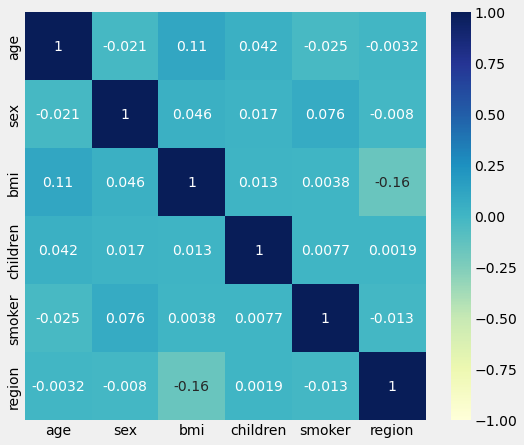

In [13]:
plt.figure(figsize=(8, 7))
sns.heatmap(X_train.corr(), annot=True, vmin=-1, vmax=1, cmap="YlGnBu")
plt.show()

#### <u>To-do:</u> Find the variance inflation factor and check if any feature must be removed.

### d. Normally distributed error terms

<AxesSubplot:xlabel='charges', ylabel='Density'>

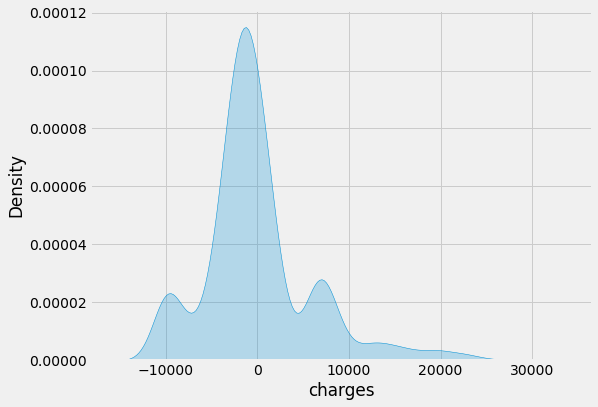

In [14]:
plt.figure(figsize=(8, 6))
sns.kdeplot(residuals, shade=True)

In [15]:
print(f"The mean of the residuals is {residuals.mean()} which is approximately {round(residuals.mean(), 4)}")

The mean of the residuals is -1.0760314745190923e-12 which is approximately -0.0


#### <u>To-do</u>: Quantile Quantile test

### e. Independent error terms

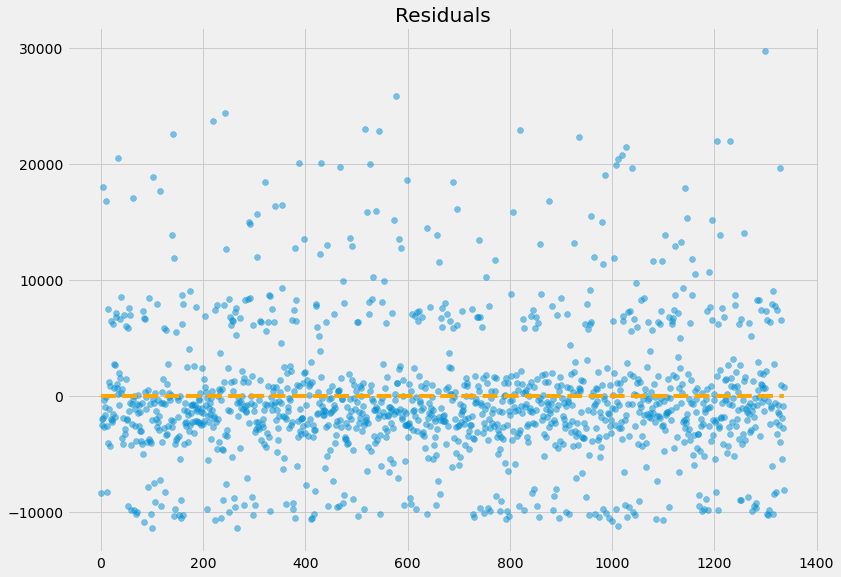

In [18]:
# pLotting the residuals

plt.subplots(figsize=(12, 9))
plt.scatter(x=residuals.index, y=residuals, alpha=0.5)
plt.plot(np.repeat(0, residuals.index.max()), color="orange", linestyle="--")
plt.title("Residuals")
plt.show()

### f. No. of observations > No. of independent variables

In [19]:
no_obs = X_train.shape[0]
no_ind_var = len(X_train.columns)

print("Are the number of observations > number of independent variables ?")
print(no_obs>no_ind_var)

Are the number of observations > number of independent variables ?
True


---